# Fase 1: Comprensión del negocio
##### Predecir el precio de vehículos usados
##### Variables: Marca, Año, Kilometraje
##### Metrica: ERROR ABSOLUTO (MAE) < 3000

## Fase 2: Compresión de datos

In [ ]:
#! pip install scikit-learn

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error

import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("cars2.csv")
df.describe()

,Year,Mileage,Price
count,51793.000000,22981.000000,5.064400e+04
mean,2020.971425,53463.782211,5.130342e+04
std,4.215305,44567.464826,3.557212e+04
min,1959.000000,0.000000,1.990000e+03
25%,2020.000000,20609.000000,3.098375e+04
50%,2023.000000,42158.000000,4.559850e+04
75%,2023.000000,73960.000000,6.310050e+04
max,2024.000000,400396.000000,1.299995e+06


##### Relación entre precio y kilometraje

Text(0, 0.5, 'Precio')

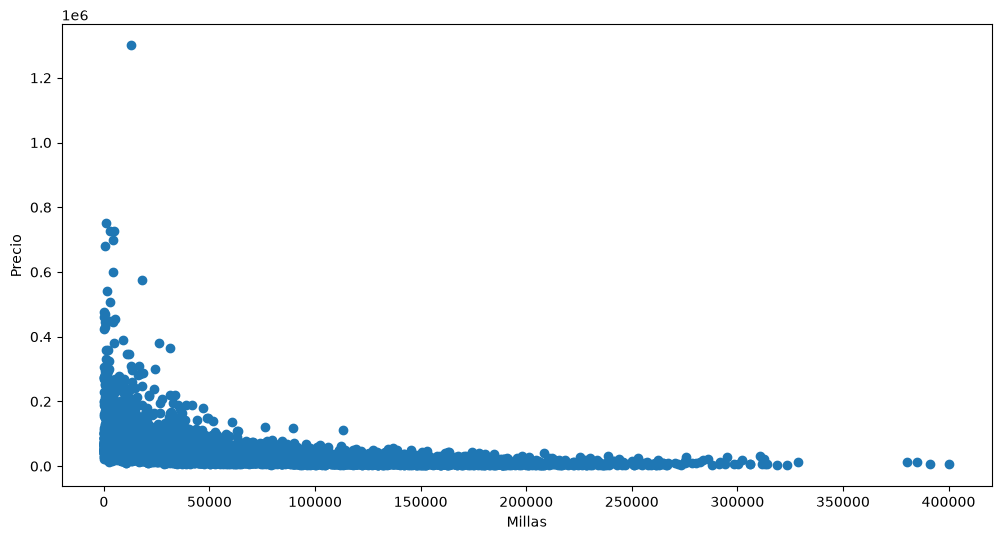

In [10]:
usados = df[ df['Status'] == 'Used' ]
plt.figure(figsize=(12, 6))
plt.scatter(usados['Mileage'], usados['Price'])
plt.xlabel('Millas')
plt.ylabel('Precio')

## Fase 3: Preparación de los datos
#### Separar autos nuevos y usados

In [4]:
df_usados = df[ df['Status'] == 'Used' ]

##### Limpiar precios incorrectos

In [25]:
df_usados = df_usados[ df_usados['Price'].between(15000, 30000) ]
df_usados = df_usados[ df_usados['Mileage'].between(1000, 100000) ]
df_usados = df_usados[ df_usados['Year'].between(2017, 2025) ]

df_usados = df_usados.dropna(subset=['Price', 'Mileage', 'Year', 'Brand'])


In [26]:
print(f"Registros limpios {len(df_usados)}")
print(f"Precio promedio {df_usados['Price'].mean()}")

Registros limpios 3928
Precio promedio 24441.29149694501


## Fase 4: Modelado

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

### Selección de datos

In [6]:
# Parametros para el estudio
X = pd.get_dummies(df_usados[['Year', 'Mileage', 'Brand']])

#Lo que se va a calcular
y = df_usados['Price']

### Separar y entrenar

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
modelo = RandomForestClassifier